In [4]:
from pathlib import Path

input_path = Path("./input/")
all_data = sorted(input_path.iterdir())
sample_data_path, test_path, train_path = all_data

In [34]:
import polars as pl
import pandas as pd

train_df_pl = pl.read_csv(train_path)
train_df_pd = pd.read_csv(train_path)
print(train_df_pl)

shape: (577_347, 12)
┌────────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ id     ┆ alpha  ┆ delta  ┆ u     ┆ g     ┆ r     ┆ i     ┆ z     ┆ redsh ┆ spect ┆ galax ┆ class │
│ ---    ┆ ---    ┆ ---    ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ift   ┆ ral_t ┆ y_pop ┆ ---   │
│ i64    ┆ f64    ┆ f64    ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ ---   ┆ ype   ┆ ulati ┆ str   │
│        ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆ f64   ┆ ---   ┆ on    ┆       │
│        ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆ str   ┆ ---   ┆       │
│        ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆ str   ┆       │
╞════════╪════════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ 0      ┆ 147.73 ┆ 16.959 ┆ 25.47 ┆ 21.89 ┆ 20.35 ┆ 19.25 ┆ 18.62 ┆ 0.408 ┆ M     ┆ Red_S ┆ GALAX │
│        ┆ 4256   ┆ 273    ┆ 2123  ┆ 5559  ┆ 7926  ┆ 7113  ┆ 1057  ┆ 9

In [35]:
test_df_pl = pl.read_csv(test_path)
test_df_pd = pd.read_csv(test_path)
print(test_df_pl)

shape: (247_435, 11)
┌────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ id     ┆ alpha  ┆ delta  ┆ u      ┆ g      ┆ r      ┆ i      ┆ z      ┆ redshi ┆ spectr ┆ galaxy │
│ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ft     ┆ al_typ ┆ _popul │
│ i64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ ---    ┆ e      ┆ ation  │
│        ┆        ┆        ┆        ┆        ┆        ┆        ┆        ┆ f64    ┆ ---    ┆ ---    │
│        ┆        ┆        ┆        ┆        ┆        ┆        ┆        ┆        ┆ str    ┆ str    │
╞════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╡
│ 577347 ┆ 120.71 ┆ 23.924 ┆ 23.668 ┆ 21.951 ┆ 21.086 ┆ 20.180 ┆ 19.202 ┆ 0.4290 ┆ G/K    ┆ Red_Se │
│        ┆ 9779   ┆ 249    ┆ 066    ┆ 68     ┆ 183    ┆ 032    ┆ 124    ┆ 42     ┆        ┆ quence │
│ 577348 ┆ 219.41 ┆ 42.171 ┆ 24.902 ┆ 22.338 ┆ 20.732 ┆ 19.860 ┆ 19.68

In [7]:
sample_df_pl = pl.read_csv(sample_data_path)
print(sample_df_pl)

shape: (247_435, 2)
┌────────┬────────┐
│ id     ┆ class  │
│ ---    ┆ ---    │
│ i64    ┆ str    │
╞════════╪════════╡
│ 577347 ┆ GALAXY │
│ 577348 ┆ GALAXY │
│ 577349 ┆ GALAXY │
│ 577350 ┆ GALAXY │
│ 577351 ┆ GALAXY │
│ …      ┆ …      │
│ 824777 ┆ GALAXY │
│ 824778 ┆ GALAXY │
│ 824779 ┆ GALAXY │
│ 824780 ┆ GALAXY │
│ 824781 ┆ GALAXY │
└────────┴────────┘


# readme関連

In [9]:
print(train_df_pl.schema)

Schema({'id': Int64, 'alpha': Float64, 'delta': Float64, 'u': Float64, 'g': Float64, 'r': Float64, 'i': Float64, 'z': Float64, 'redshift': Float64, 'spectral_type': String, 'galaxy_population': String, 'class': String})


# eda

In [ ]:
# クラスの確認

print(train_df_pl["class"].unique())

shape: (3,)
Series: 'class' [str]
[
	"STAR"
	"QSO"
	"GALAXY"
]


In [12]:
# 入力データに none が存在するかの確認
pl.Config.set_tbl_cols(-1)

print(train_df_pl.null_count())

shape: (1, 12)
┌─────┬───────┬───────┬─────┬─────┬─────┬─────┬─────┬──────────┬─────────────┬─────────────┬───────┐
│ id  ┆ alpha ┆ delta ┆ u   ┆ g   ┆ r   ┆ i   ┆ z   ┆ redshift ┆ spectral_ty ┆ galaxy_popu ┆ class │
│ --- ┆ ---   ┆ ---   ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ ---      ┆ pe          ┆ lation      ┆ ---   │
│ u32 ┆ u32   ┆ u32   ┆ u32 ┆ u32 ┆ u32 ┆ u32 ┆ u32 ┆ u32      ┆ ---         ┆ ---         ┆ u32   │
│     ┆       ┆       ┆     ┆     ┆     ┆     ┆     ┆          ┆ u32         ┆ u32         ┆       │
╞═════╪═══════╪═══════╪═════╪═════╪═════╪═════╪═════╪══════════╪═════════════╪═════════════╪═══════╡
│ 0   ┆ 0     ┆ 0     ┆ 0   ┆ 0   ┆ 0   ┆ 0   ┆ 0   ┆ 0        ┆ 0           ┆ 0           ┆ 0     │
└─────┴───────┴───────┴─────┴─────┴─────┴─────┴─────┴──────────┴─────────────┴─────────────┴───────┘


10.741818904876709


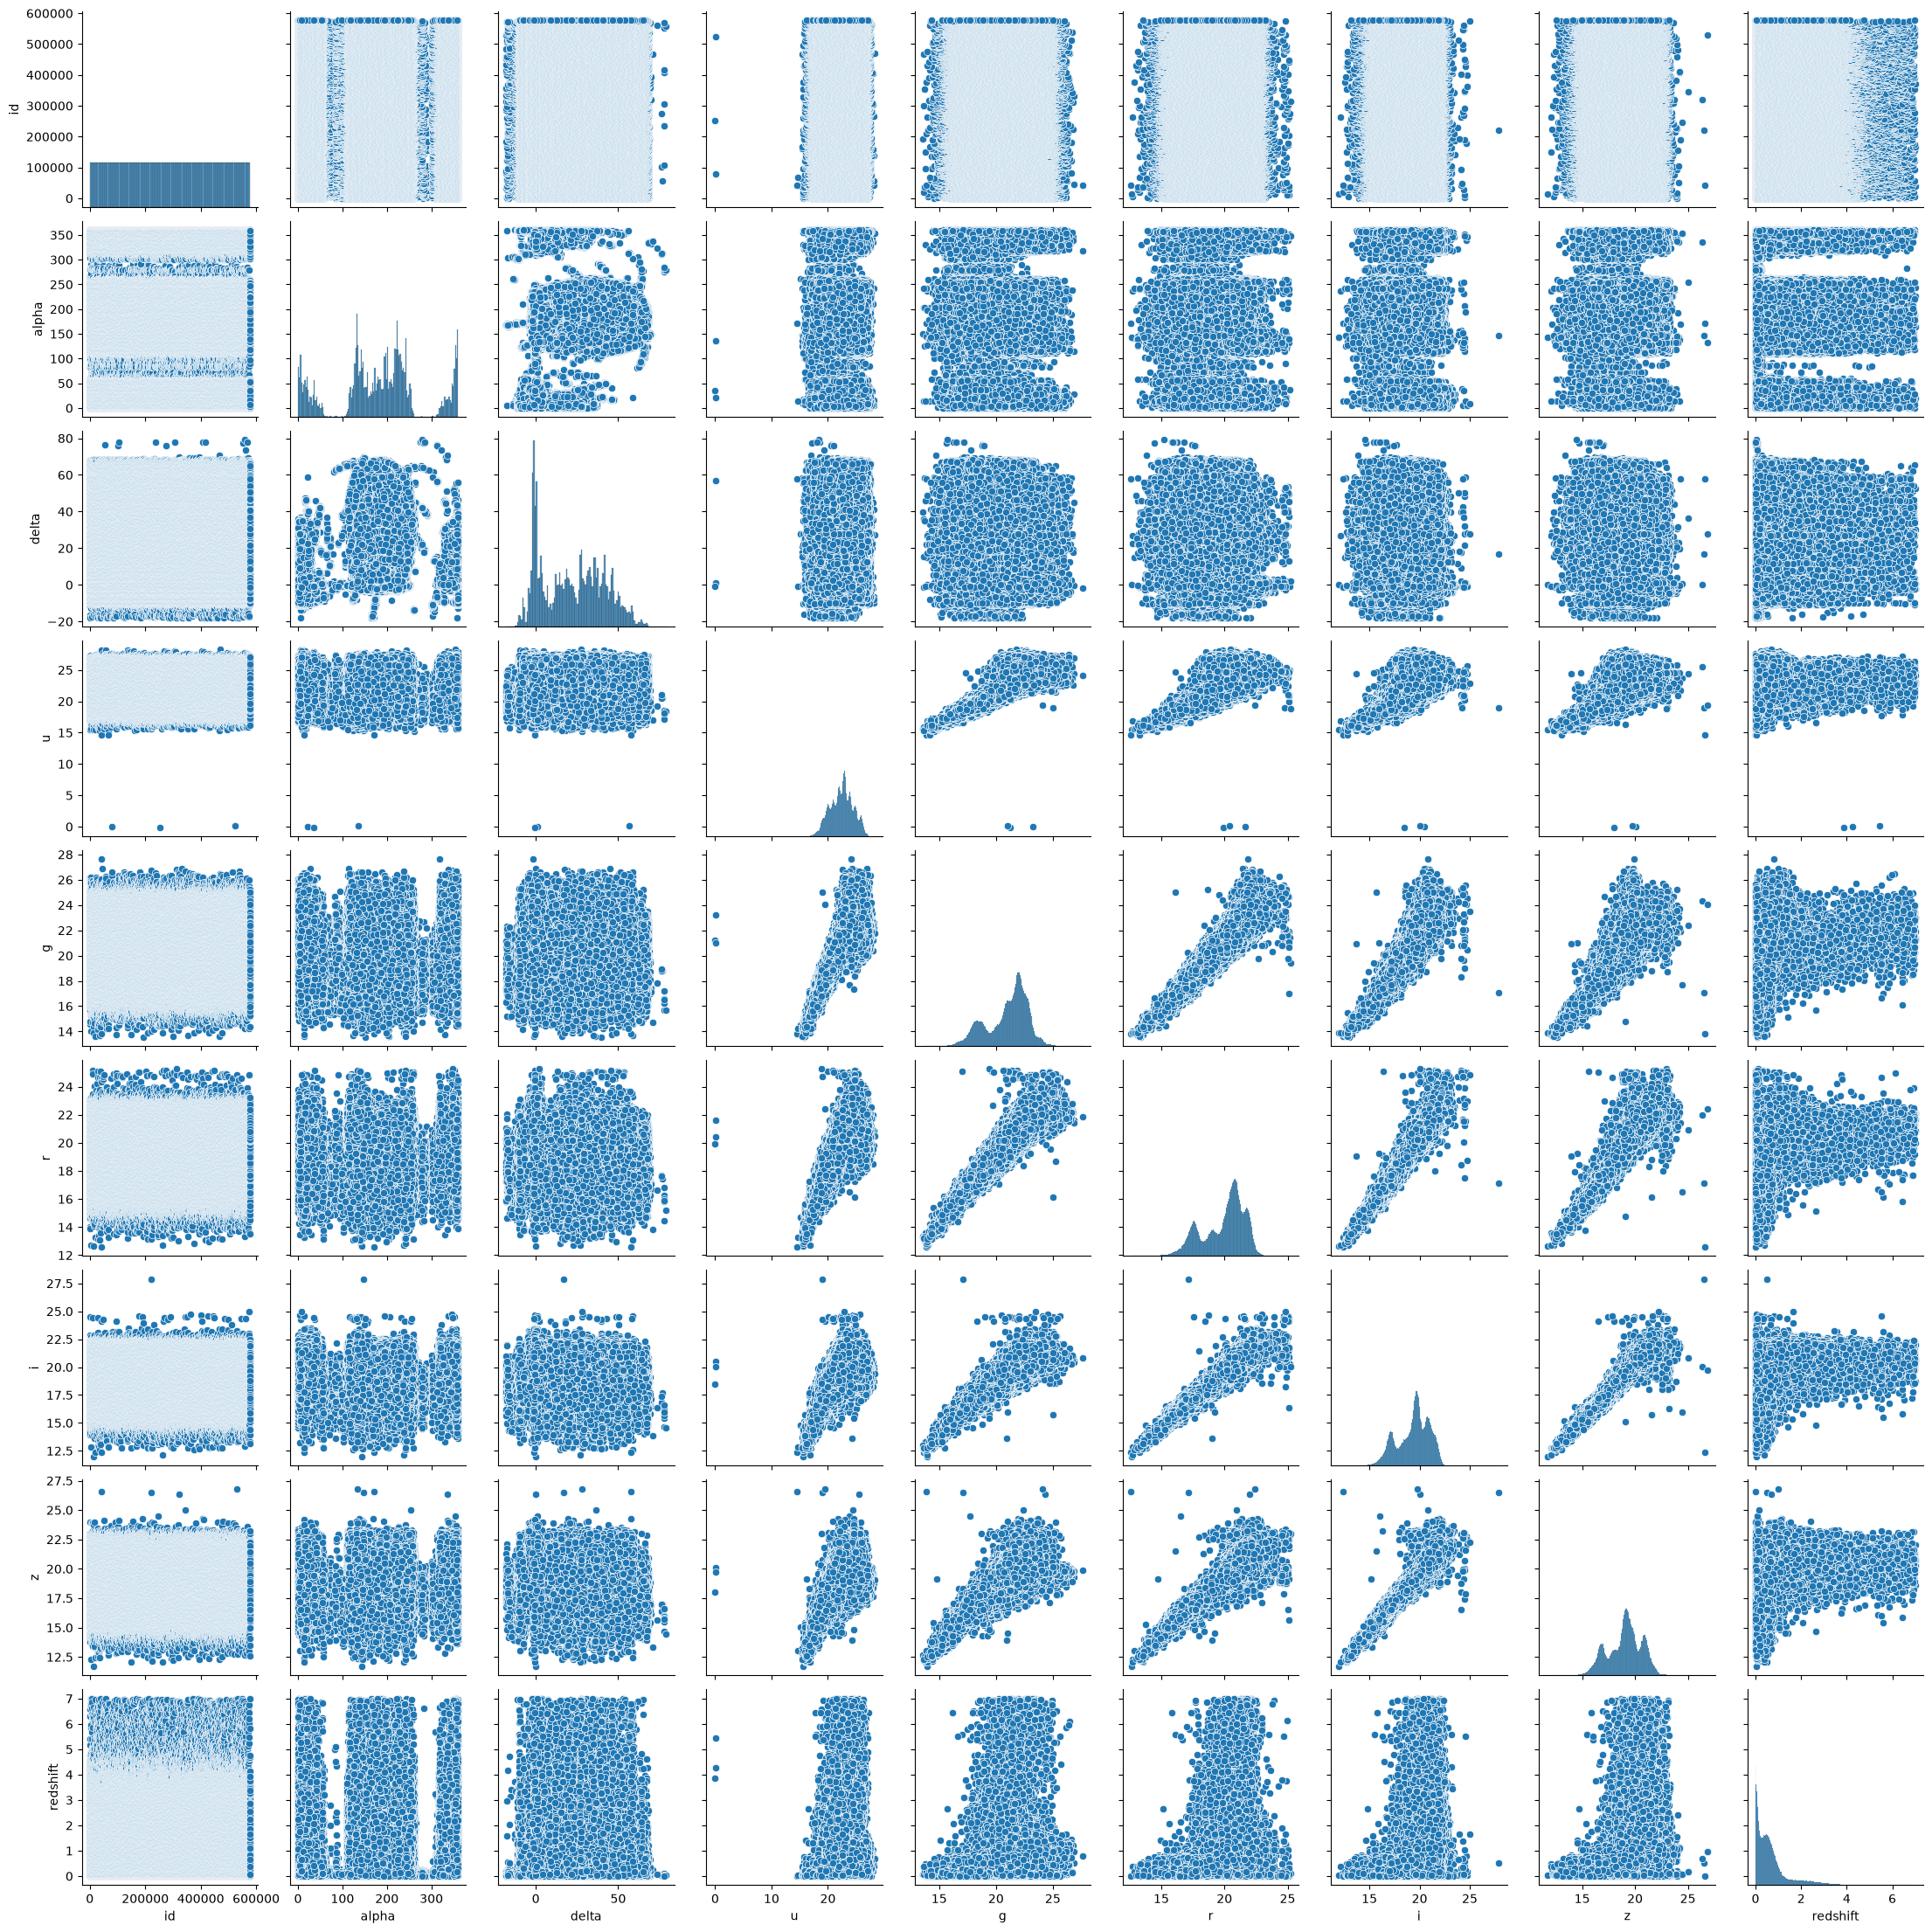

In [36]:
# pairplot の描画

import seaborn as sns
import time

start = time.time()
sns.pairplot(train_df_pd)
end = time.time()
diff = end - start
print(diff)

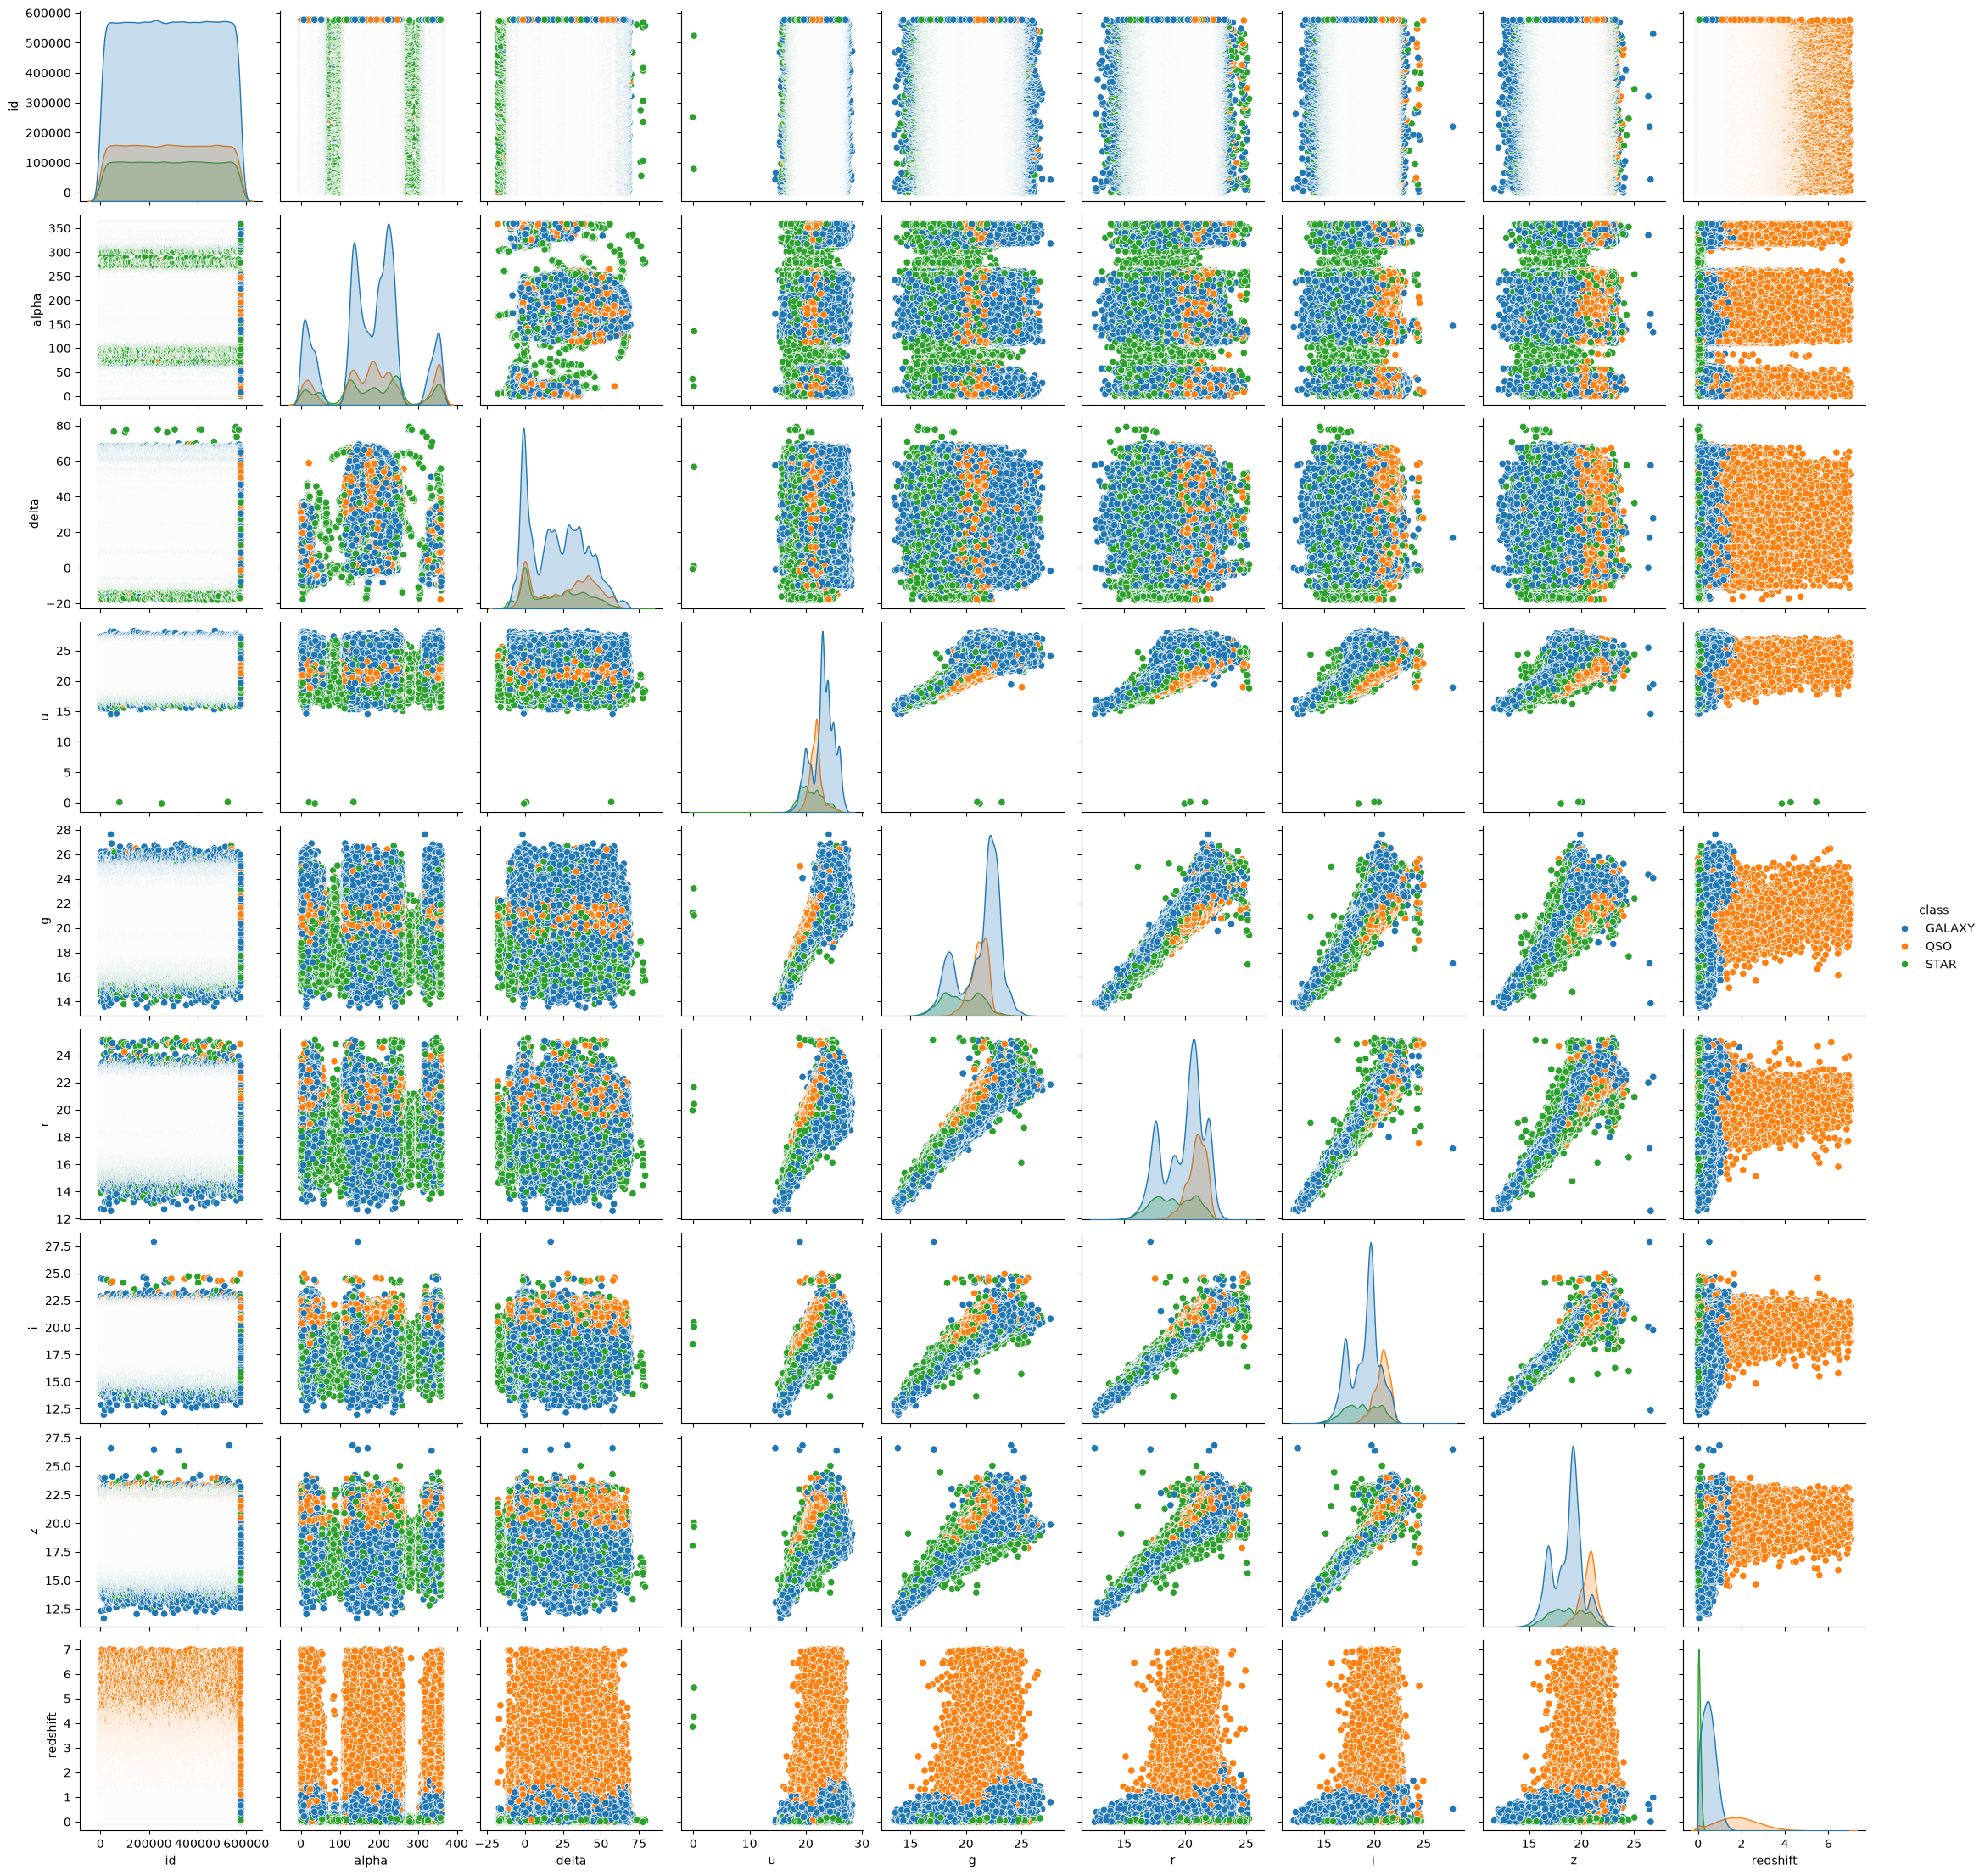

In [ ]:
# class での描画

sns.pairplot(train_df_pd, hue="class")

"""
stellar と galaxy の分類精度の肝になりそう
"""